## TP3: CNN

Ce TP est composé de cinq parties. 

- La première partie est une introduction à l'utilisation de Pytorch avec CUDA.
- La deuxième partie implémente et entraîne un MLP sur MNIST.
- La troisième partie implémente et entraîne un CNN sur MNIST.
- La quatrième partie compare les capacités de généralisation des modèles appris sur des images translatées.
- La cinquième partie compare les capacités des modèles à apprendre sans overffitting sur des petits jeux de données.

Pour commencer, importez les packages suivants:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import time

import torch
from torchvision import datasets, transforms

### Partie 1. Utiliser Pytorch avec CUDA

CUDA est une plateforme de calcul parallèle et un modèle de programmation développée par NVIDIA qui permet d'utiliser les processeurs graphiques (GPU) pour accélérer les calculs. Dans le contexte de PyTorch, CUDA permet d'exécuter des opérations sur tenseurs beaucoup plus rapidement sur GPU que sur CPU, ce qui est essentiel pour l'entraînement de réseaux de neurones profonds.

Pour vérifier que CUDA est bien installé et que Pytorch détecte correctement qu'il peut utiliser le calcul sur GPU via CUDA, on peut lancer la commande suivante:

In [2]:
# Renvoie True si un GPU est disponible, sinon False
# Sur les Jupyterlab du département, vous devez obtenir True
torch.cuda.is_available()

True

Quand on utiliser Pytorch avec CUDA, on va devoir faire quelques manipulations supplémentaires par rapport à une utilisation "classique" de Pytorch sur CPU (ce qu'on faisait au dernier TP):
1. Définir un `device` qui indique où les calculs doivent être effectués (GPU ou CPU)
2. Déplacer les tenseurs et les modèles sur ce `device` en utilisant la méthode `.to(device)`
3. S'assurer que toutes les données (entrées, labels, paramètres du modèle) sont sur le même `device` avant d'effectuer des opérations

De plus, avant de quitter la salle de TP, il faudra veiller à libérer la mémoire des GPUs en interrompant ou redémarrant le kernel.

In [3]:
# Définir un device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instancier un tenseur pour l'exemple
x = torch.randn(3, 3)

# Déplacer le tenseur vers le device
x = x.to(device)

# On voit que le tenseur est bien sur le GPU (s'il est disponible)
print(x)

tensor([[ 0.0700,  0.2770, -0.5387],
        [-1.0483, -1.1738,  1.8535],
        [ 0.9194,  0.8950, -1.9549]], device='cuda:0')


La cellule suivante permet d'afficher l'utilisation actuelle de la mémoire du GPU par le process courant (ce kernel Jupyter).

In [4]:
t = torch.cuda.get_device_properties(0).total_memory / 1024**2
r = torch.cuda.memory_reserved(0) / 1024**2

# Afficher les informations de mémoire en Mo
print(f"Mémoire totale: {t} Mo, Mémoire réservée: {r} Mo")

Mémoire totale: 48569.625 Mo, Mémoire réservée: 2.0 Mo


La cellule suivante permet d'afficher l'utilisation totale de la mémoire du GPU (comprenant les autres groupes de TP qui sont sur le même GPU).

In [5]:
! nvidia-smi

Wed Feb 25 01:30:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:01:00.0 Off |                  Off |
| 30%   30C    P2             65W /  300W |    7510MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Partie 2. Entraînement d'un MLP sur MNIST

Dans cette partie, on va utiliser le MLP implémenté dans la cellule suivante:

In [6]:
class MLP(torch.nn.Module):
    """Class implementing a three-layered MLP with BatchNorm and Dropout.

    Attributes
    ----------
        input_size : int
            Dimension of the input
        hidden_size : int
            Dimension of the hidden layers
        output_size : int
            Dimension of the output
        linear1 : torch.nn.Linear
            First linear layer
        bn1 : torch.nn.BatchNorm
            First batch norm layer
        linear2 : torch.nn.Linear
            Second linear layer
        bn2 : torch.nn.BatchNorm
            Second batch norm layer
        linear3 : torch.nn.Linear
            Third linear layer
        """

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.linear1 = torch.nn.Linear(input_size, hidden_size)
        self.bn1 = torch.nn.BatchNorm1d(hidden_size)
        self.linear2 = torch.nn.Linear(hidden_size, hidden_size)
        self.bn2 = torch.nn.BatchNorm1d(hidden_size)
        self.linear3 = torch.nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        """Forward pass through the MLP

        Parameters
        ----------
            x : torch.tensor of shape (batch_size, input_size)

        Returns
        -------
            torch.tensor of shape (batch_size, output_size)
        """
        x = x.view(-1, 28*28)
        x = torch.relu(self.bn1(self.linear1(x)))
        x = torch.relu(self.bn2(self.linear2(x)))
        x = self.linear3(x)
        return x

Les cellules suivantes préparent les données (comme dans le TP2) et entraînent le modèle:

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

train_dataset = datasets.MNIST(
    root='./data/deep_learning/tp2', train=False, download=False, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data/deep_learning/tp2', train=False, download=False, transform=transform
)

# Affichage de la taille d'une image
print(train_dataset[0][0].shape)

torch.Size([1, 28, 28])


In [8]:
from torch.utils.data import DataLoader

# Hyperparamètres fixes
batch_size = 100  # Taille des batchs
epochs = 10  # Nombre d'époques
hidden_size = 128  # Taille des couches intermédiaires

# L'option shuffle=True est importante pour le jeu d'entraînement
# Elle permet de mélanger les données à chaque époque
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [79]:
start = time.time()

mlp_model = MLP(
    input_size=28*28,  # Dimension des images MNIST
    output_size=10,  # Nombre de classes
    hidden_size=hidden_size,
)

# A compléter question 1
...

# Pour passer sur GPU :
mlp_model = mlp_model.to(device)

train_loss = []
test_loss = []

train_accuracy = []
test_accuracy = []

optimizer = torch.optim.AdamW(mlp_model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(epochs):

    # ============= Phase d'entraînement ============
    mlp_model.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    training_running_loss = 0.0  # Pour accumuler la loss sur l'époque
    training_running_correct = 0  # Pour accumuler le nombre de bonnes prédictions
    training_total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, labels in tqdm(train_loader):

        # A compléter question 1
        ...

        # Pour le GPU :
        images = images.to(device)
        labels = labels.to(device)

        # On metles gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurone et la fonction de coût
        outputs = mlp_model(images)
        loss = loss_fn(outputs, labels)

        # On sauvegarde les statistiques
        training_running_loss += loss.item() * images.size(0)
        # La classe prédite est celle avec la plus grande activation
        predicted = torch.argmax(outputs, dim=1)
        training_running_correct += (predicted == labels).sum().item()
        training_total += labels.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = training_running_loss / training_total
    epoch_accuracy = training_running_correct / training_total
    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_accuracy)

    # ============= Phase d'évaluation ============
    mlp_model.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, labels in test_loader:
            
            # A compléter question 1
            ...
            
            # Pour le GPU :
            images = images.to(device)
            labels = labels.to(device)

            outputs = mlp_model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    test_loss.append(epoch_loss)
    test_accuracy.append(epoch_accuracy)

end = time.time()

print(f"L'entraînement a duré {round(end - start, 2)} secondes")

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

L'entraînement a duré 30.55 secondes


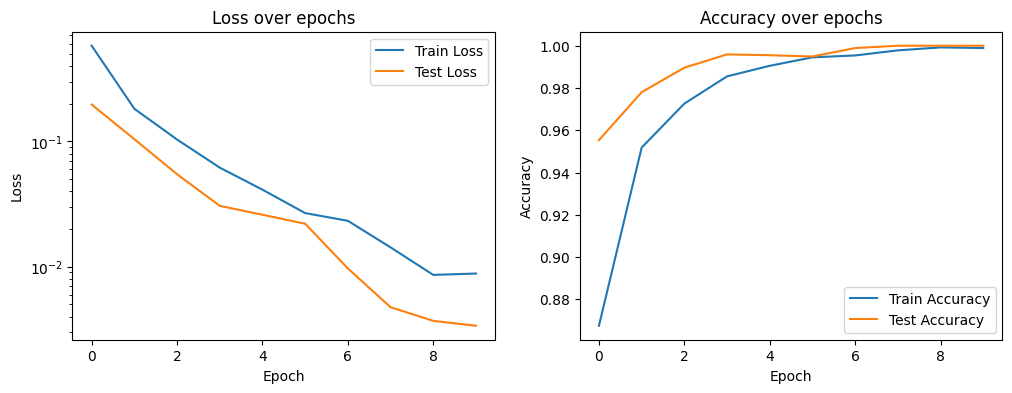

In [80]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

#### Question 1.

Modifiez le code de la cellule qui réalise l'entraînement afin de faire les calculs sur GPU (par défaut ils sont fait sur CPU).

Pour cela, il faut:
- Mettre le modèle sur le GPU juste après l'avoir instancié avec l'instruction mlp_model = mlp_model.to(device)
- Mettre les images et labels envoyés par le dataloader sur le GPU, avec la même instruction

Comparez le temps d'entraînement sur CPU et sur GPU.

### Partie 3. Entraînement d'un CNN sur MNIST

Dans cette partie nous allons implémenter un CNN inspiré de LeNet5 http://yann.lecun.com/exdb/publis/pdf/lecun-98.pdf
![LeNet5](https://miro.medium.com/max/2000/1*1TI1aGBZ4dybR6__DI9dzA.png)

Ce réseau est composé de deux couches de convolution, deux couches de subsampling, et trois couches entièrement connectée (= couche linéaire). Dans cette représentation, les fonctions d'activation ne sont pas représentées et sont implicites.

#### Question 2.

Implémentez le réseau ci-dessus.
- Pour les couches de convolution, on utilisera le module torch.nn.Conv2d
- Comme fonction d'activation après les couches de convolution et linéaires (à l'exception de la dernière couche).
- Comme méthode de subsampling, on utilisera le average pooling (torch.nn.AvgPool2d)
- On ajoutera des couches de normalisation par batch avant les fonctions d'activations. On utilisera BatchNorm2d pour les couches de CNNs, et BatchNorm1d pour les couches linéaires.
- La méthode forward est donnée pour vous guider.

In [81]:
class CNNModel(torch.nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # CNN
        ...
        # Couche 1 : Convolution + Batch Normalization + Average Pooling
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.bn1 = torch.nn.BatchNorm2d(6)
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        # Couche 2 : Convolution + Batch Normalization + Average Pooling
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.bn2 = torch.nn.BatchNorm2d(16)
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        

        # Classifieur MLP
        ...
        
        # Les features extraites ont une shape de (16 channels, 5, 5) => 16 * 5 * 5 = 400
        self.fc1 = torch.nn.Linear(in_features=400, out_features=120)
        self.bn3 = torch.nn.BatchNorm1d(120)
        
        self.fc2 = torch.nn.Linear(in_features=120, out_features=84)
        self.bn4 = torch.nn.BatchNorm1d(84)
        
        self.fc3 = torch.nn.Linear(in_features=84, out_features=10)
        
    def forward(self, x):
        # On commence par des couches de convolutions et upsampling
        x = torch.relu(self.bn1(self.conv1(x)))
        #print(f"Couche 1: x.shape = {x.shape}")
        x = self.pool1(x)
        #print(f"Couche 2: x.shape = {x.shape}")
        x = torch.relu(self.bn2(self.conv2(x)))
        #print(f"Couche 3: x.shape = {x.shape}")        
        x = self.pool2(x)
        #print(f"Couche 4: x.shape = {x.shape}")

        # Convertit le tenseur de shape (batch_size, 16, 5, 5) en un tenseur de shape (batch_size, 400)
        x = torch.flatten(x, 1)
        #print(f"Flatten: x.shape = {x.shape}")

        # Partie MLP pour la fin
        x = torch.relu(self.bn3(self.fc1(x)))
        #print(f"Couche 5: x.shape = {x.shape}")
        x = torch.relu(self.bn4(self.fc2(x)))
        #print(f"Couche 6: x.shape = {x.shape}")
        x = self.fc3(x)
        #print(f"Couche 7: x.shape = {x.shape}")

        return x

cnn_model = CNNModel()

#### Question 3.

Utilisez la cellule suivante pour tester votre implémentation. 
Il est très probable que vous ayez une erreur de la forme: RuntimeError: mat1 and mat2 shapes cannot be multiplied (7x256 and 400x120)

Cette erreur provient du fait que LeNet5 est conç pour des images de dimension (32, 32) alors que MNIST a des images de dimension (28, 28).

Modifiez le padding de la première couche de manière à "faire comme si" les images étaient de dimension (32, 32). Vous pouvez vous aidez des affichages dans la méthode forward() pour suivre l'évolution des shape des tenseurs dans les couches intermédiaires.

Une fois que la cellule suivante s'exécute sans erreur, retirez tous les print dans la méthode forward().

In [82]:
batch_size = 7
x = torch.randn(batch_size, 1, 28, 28)
_ = cnn_model(x)

#### Question 4.

Entraînez le modèle grâce à la cellule suivante:

Comme pour le MLP, comparez le temps de calcul sur CPU et GPU.

In [83]:
start = time.time()

cnn_model = CNNModel()

# A compléter
...

cnn_model = cnn_model.to(device)

train_loss = []
test_loss = []

train_accuracy = []
test_accuracy = []

optimizer = torch.optim.AdamW(cnn_model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(epochs):

    # ============= Phase d'entraînement ============
    cnn_model.train()  # On met le modèle en mode entraînement (utile pour dropout/batchnorm)

    training_running_loss = 0.0  # Pour accumuler la loss sur l'époque
    training_running_correct = 0  # Pour accumuler le nombre de bonnes prédictions
    training_total = 0  # Pour accumuler le nombre d'exemples vus

    # On itère sur tous les batchs du jeu d'entraînement
    for images, labels in tqdm(train_loader):
        
        # A compléter
        ...

        images = images.to(device)
        labels = labels.to(device)

        # On met les gradients à zéro avant la rétro-propagation
        optimizer.zero_grad()

        # Passe forward dans le réseau de neurone et la fonction de coût
        outputs = cnn_model(images)
        loss = loss_fn(outputs, labels)

        # On sauvegarde les statistiques
        training_running_loss += loss.item() * images.size(0)
        
        # La classe prédite est celle avec la plus grande activation
        predicted = torch.argmax(outputs, dim=1)
        training_running_correct += (predicted == labels).sum().item()
        training_total += labels.size(0)

        # Rétro-propagation et mise à jour des poids
        loss.backward()
        optimizer.step()

    # On sauvegarde la loss et l'accuracy de l'époque
    epoch_loss = training_running_loss / training_total
    epoch_accuracy = training_running_correct / training_total
    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_accuracy)

    # ============= Phase d'évaluation ============
    cnn_model.eval()  # On met le modèle en mode évaluation (utile pour dropout/batchnorm)
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():  # Pas besoin de calculer les gradients en évaluation
        for images, labels in test_loader:
            # A compléter
            ...

            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    test_loss.append(epoch_loss)
    test_accuracy.append(epoch_accuracy)

end = time.time()

print(f"L'entraînement a duré {round(end - start, 2)} secondes")

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

L'entraînement a duré 32.18 secondes


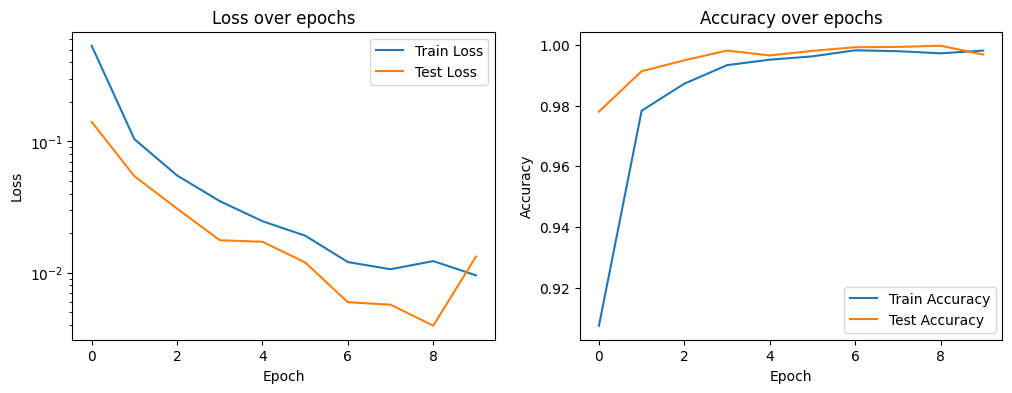

In [84]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

#### Question 5.

Essayez manuellement de donner un ordre de grandeur du nombre de paramètres aprenables pour le MLP et le CNN. D'après vous, quel modèle contient le plus de paramètres ?

Lancez la cellule suivante pour vérifier vos estimations:

In [85]:
mlp_total_params = sum(p.numel() for p in mlp_model.parameters())
cnn_total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Nombre de paramètres du MLP: {mlp_total_params}")
print(f"Nombre de paramètres du CNN: {cnn_total_params}")

Nombre de paramètres du MLP: 118794
Nombre de paramètres du CNN: 62158


### 4. Expériences avec des translations

La différence de performance entre les deux méthodes, malgré le nombre plus grand de paramètres pour le MLP, provient du fait que le MLP doit "découvrir" par lui même certaines règles qui sont déjà implémentée implicitement dans l'architecture du CNN.

C'est le cas notamment de l'invariance par translation. Les couches d'upsampling implémente cette invariance, ce qui veut dire que la valeur de la sortie de ces couches n'est pas affectée par des petites translations des images d'entrées. C'est un comportement qui est désirable pour la classification d'écriture manuscrite. Si l'image est légèrement décalée, que le chiffre est mal centré, on veut que le réseau de neurones le reconnaissent quand même.

Dans cette partie, nous allons manuellement appliquer des petites translations aux images, et analyser leur effet sur la performance de classification des deux modèles entraînés.

Pour commencez, exécutez la cellule suivante qui prépare la fonction dont nous aurons besoin pour appliquer des translations aux données.

In [86]:
def translation(x, max_shift):
    """ Applies a translation of maximum amplitude `shift` to a given batch

    Parameters
    ----------
        x: torch.Tensor of shape (batch_size, 1, 28, 28)

    Returns
    -------
        torch.Tensor of shape (batch_size, 1, 28, 28)
        translated x 
    """
    if max_shift == 0:
        return x

    batch_size, channels, height, width = x.shape
    out = x.clone()

    dx = torch.randint(-max_shift, max_shift + 1, (batch_size,), device=x.device)
    dy = torch.randint(-max_shift, max_shift + 1, (batch_size,), device=x.device)

    for i in range(batch_size):
        out[i] = torch.roll(out[i], shifts=(dy[i].item(), dx[i].item()), dims=(-2, -1))

        # zero out wrapped regions (so roll doesn't wrap content)
        if dy[i] > 0:
            out[i, :, :dy[i], :] = 0
        elif dy[i] < 0:
            out[i, :, dy[i]:, :] = 0

        if dx[i] > 0:
            out[i, :, :, :dx[i]] = 0
        elif dx[i] < 0:
            out[i, :, :, dx[i]:] = 0

    return out

#### Question 6. 

Compléter la fonction evaluate, permettant d'évaluer un modèle (le CNN ou le MLP) sur les données de test, tout en appliquant la translation avec la fonction définie précédemment.

Si votre fonction est correctement implémentée, vous devriez retrouver avec max_shift=0 les mêmes test_accuracy qu'à la fin des entraînements respectifs des deux modèles.

In [87]:
def evaluate(model, loader, max_shift=0):
    model.eval()

    # A compléter
    ...

    model = model.to(device)

    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
    
            # A compléter
            ...
            x = x.to(device)
            y = y.to(device)

            x_translated = translation(x, max_shift)
            
            # On passe les images translatées dans le modèle
            outputs = model(x_translated)
            
            # On récupère la classe prédite (l'indice de la plus forte probabilité)
            y_predicted = torch.argmax(outputs, dim=1)
            
            # On met à jour nos compteurs
            correct += (y_predicted == y).sum().item()
            total += y.size(0)

    accuracy = correct / total

    return accuracy

#### Question 7.

Evaluez les deux modèles sur différentes valeurs pour l'amplitude maximale de translation d'images, et affichez vos résultats.

Si le CNN était complètement "translation invariant" alors son accuracy devrait rester identique peu importe la translation appliquée. Comment expliquer que le score se dégrade ?

  0%|          | 0/11 [00:00<?, ?it/s]

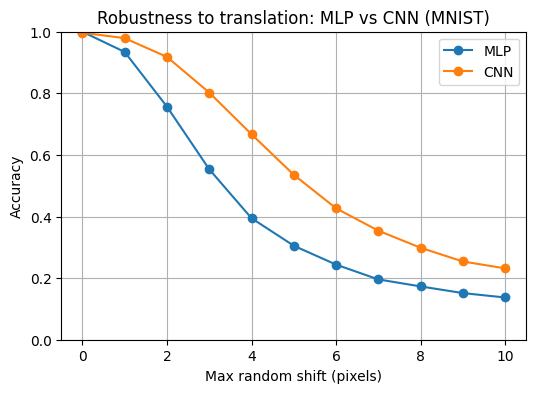

In [88]:
shift_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

results = []
for s in tqdm(shift_values):
    mlp_acc = evaluate(mlp_model, test_loader, max_shift=s)
    cnn_acc = evaluate(cnn_model, test_loader, max_shift=s)
    results.append((mlp_acc, cnn_acc))

mlp_accs = [r[0] for r in results]
cnn_accs = [r[1] for r in results]

plt.figure(figsize=(6,4))
plt.plot(shift_values, mlp_accs, marker="o", label="MLP")
plt.plot(shift_values, cnn_accs, marker="o", label="CNN")
plt.xlabel("Max random shift (pixels)")
plt.ylabel("Accuracy")
plt.title("Robustness to translation: MLP vs CNN (MNIST)")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.show()


### Évaluation et analyse de l'invariance à la translation

**1. Observation des résultats attendus**
Lorsqu'on augmente l'amplitude de la translation, la précision (accuracy) des deux modèles diminue. Bien que le CNN soit nettement plus robuste et surperforme le modèle MLP (qui s'effondre très rapidement), le score du CNN finit tout de même par se dégrader face à de fortes translations.

**2. Pourquoi le score du CNN se dégrade-t-il ?**
Il est courant de dire que les CNN sont "translation invariant", mais en réalité, ils ne possèdent qu'une invariance **locale** et non globale. La dégradation du score s'explique par plusieurs facteurs :

* **Les couches denses (Fully Connected) brisent l'invariance :** Si les couches de convolution détectent bien les formes peu importe où elles se trouvent (équivariance), les données sont généralement aplaties (*Flatten*) à la fin du réseau pour entrer dans une couche linéaire (`Linear`). Cette couche dense associe des poids à des positions spatiales précises. Si la translation est trop grande, les activations arrivent sur des neurones qui n'ont pas appris à traiter ces informations.
* **L'invariance du Pooling est limitée :** Les couches de sous-échantillonnage (*Max-Pooling*) apportent une invariance aux translations, mais elle est strictement **locale** (limitée à la taille du filtre, souvent 2x2). Elles ne peuvent pas compenser une translation de plusieurs pixels.
* **Perte d'information par recadrage (Cropping) :** Lors d'une forte translation, une partie de l'objet (ex: un chiffre MNIST) sort tout simplement du cadre de l'image (28x28) et disparaît. Le réseau perd des caractéristiques essentielles pour faire sa prédiction, tandis que l'espace vide est rempli de zéros (padding).
* **Biais du jeu de données d'entraînement :** Si le modèle a été entraîné uniquement sur des images bien centrées, il n'a jamais appris à reconnaître des objets situés sur les bords extrêmes de l'image.

**Conclusion :** Pour rendre un CNN véritablement robuste aux fortes translations, il ne suffit pas de compter sur son architecture. Il faut utiliser l'**augmentation de données** (Data Augmentation) pendant l'entraînement, en lui montrant artificiellement des images décalées.